In [3]:
import pandas as pd

In [4]:
dataset = pd.read_csv("risk_factors_cervical_cancer.csv")
pd.set_option('display.max_columns', None)
dataset.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0


Esse dataset foca na predição de fator de risco do câncer do colo do útero, ele foi coletado no hospital universitário de Caracas na Venezuela e abrange informações demográficas, habitos, registros médicos históricos e contém 4 targets são eles Hinselmann, Schiller citology e Biopsy, todos são exames, sendo que a Biopsy é a mais representativa. Neste trabalho a intenção é criar um modelo que seja capaz de fazer a triagem das pacientes.

Algumas pacientes decidiram não responder todas questões por preocupações com a privacidade, por isso existem campos vazios, esses campos foram preenchidos com interrogação.  

A leitura do dataset será realizada agora com a substituição das interrogações por nulos para facilitar a análise.

In [5]:
dataset = pd.read_csv("risk_factors_cervical_cancer.csv", na_values='?')
dataset.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


In [6]:
dataset.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,832.000000,851.000000,802.000000,845.000000,845.000000,845.000000,750.000000,750.000000,741.000000,741.000000,753.000000,753.000000,753.000000,753.0,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.0,753.000000,753.000000,753.000000,858.000000,71.000000,71.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,2.527644,16.995300,2.275561,0.145562,1.219721,0.453144,0.641333,2.256419,0.112011,0.514804,0.104914,0.176627,0.058433,0.0,0.005312,0.057105,0.023904,0.001328,0.001328,0.001328,0.0,0.023904,0.001328,0.002656,0.087413,6.140845,5.816901,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,1.667760,2.803355,1.447414,0.352876,4.089017,2.226610,0.479929,3.764254,0.315593,1.943089,0.306646,0.561993,0.234716,0.0,0.072739,0.232197,0.152853,0.036442,0.036442,0.036442,0.0,0.152853,0.036442,0.051503,0.302545,5.895024,5.755271,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,8.000000,7.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,19.000000,1.000000,4.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,3.000000,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


* Pacientes jovens, possível assimetria (tem alguns mais velhos puxando a média).
* A maioria tem poucos parceiros, existem outliers fortes.
* Primeira relação sexual com média de 17 anos, mínimo com 10, é um erro ou caso real?
* Gravidez com média de 2, mas com outliers.
* Poucos fumantes.
* Mais da metade usa contraceptivos hormonais com tempo de uso muito variável.
* As DSTs são raras, quase sempre zero.
* As target também são raras, logo temos uma dataset desbalanceado.
* As colunas **STDs:AIDS** e **STDs:cervical condylomatosis** só tem um valor para todos os pacientes, não tem variabilidade, então não servem.



In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

As colunas **STDs: Time since first diagnosis** e **STDs: Time since last diagnosis** tem mais de 90% de de valores faltantes, a princípio foi pensado em removê-las, mas pode ser porque as DSTs são raras, então faz sentido mantê-las, considerando também que o dataset é pequeno.

É possível notar também que existem muitas questões que não foram respondidas e precisam de tratamento, o fato dos pacientes terem se recusado a responder as questões pode ser uma informação valiosa na análise estatística, então os nulos serão tratados com a média e será aplicado o **indicador de missing** que é uma nova coluna capaz de representar se a questão foi respondida ou não.

A escolha da **média** faz sentido se associar ela às novas colunas, então o modelo pode aprender e entender esse comportamento.

In [8]:

# dataset.drop(['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis'], axis=1, inplace=True)

colunas = dataset.columns.tolist()

for col in colunas:

    if dataset[col].isnull().any():

        # Cria a nova coluna, 1 (Respondeu) e False em 0 (Não respondeu).
        nome_nova_coluna = f"{col}_preenchido"
        dataset[nome_nova_coluna] = dataset[col].notnull().astype(int)

        media = dataset[col].mean()

        dataset.fillna({col: media}, inplace=True)

dataset.isnull().sum()

,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
...,...
STDs:HIV_preenchido,0
STDs:Hepatitis B_preenchido,0
STDs:HPV_preenchido,0
STDs: Time since first diagnosis_preenchido,0


In [9]:
dataset.nunique()

,0
Age,44
Number of sexual partners,13
First sexual intercourse,22
Num of pregnancies,12
Smokes,3
...,...
STDs:HIV_preenchido,2
STDs:Hepatitis B_preenchido,2
STDs:HPV_preenchido,2
STDs: Time since first diagnosis_preenchido,2


In [10]:
dataset['STDs:AIDS'].value_counts()

,count
STDs:AIDS,
0.0,858


In [11]:
dataset['STDs:cervical condylomatosis'].value_counts()

,count
STDs:cervical condylomatosis,
0.0,858


Comprovado que nenhum dos pacientes teve essas DSTs então podem ser removidas do dataset.

In [12]:
dataset.drop(['STDs:AIDS', 'STDs:cervical condylomatosis'], axis=1, inplace=True)

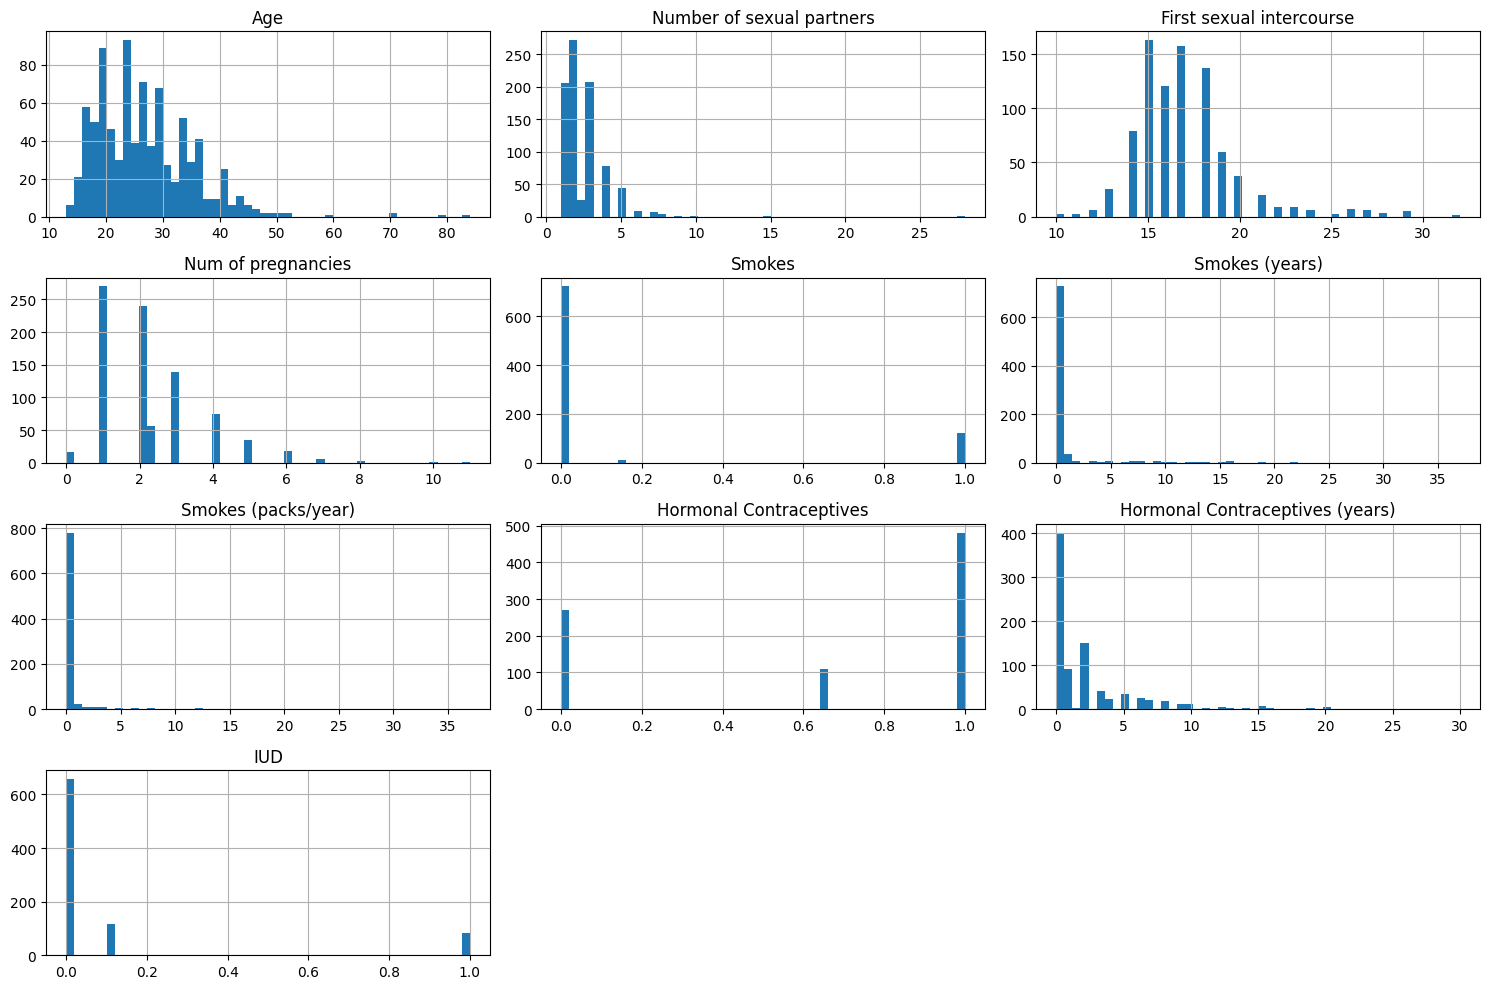

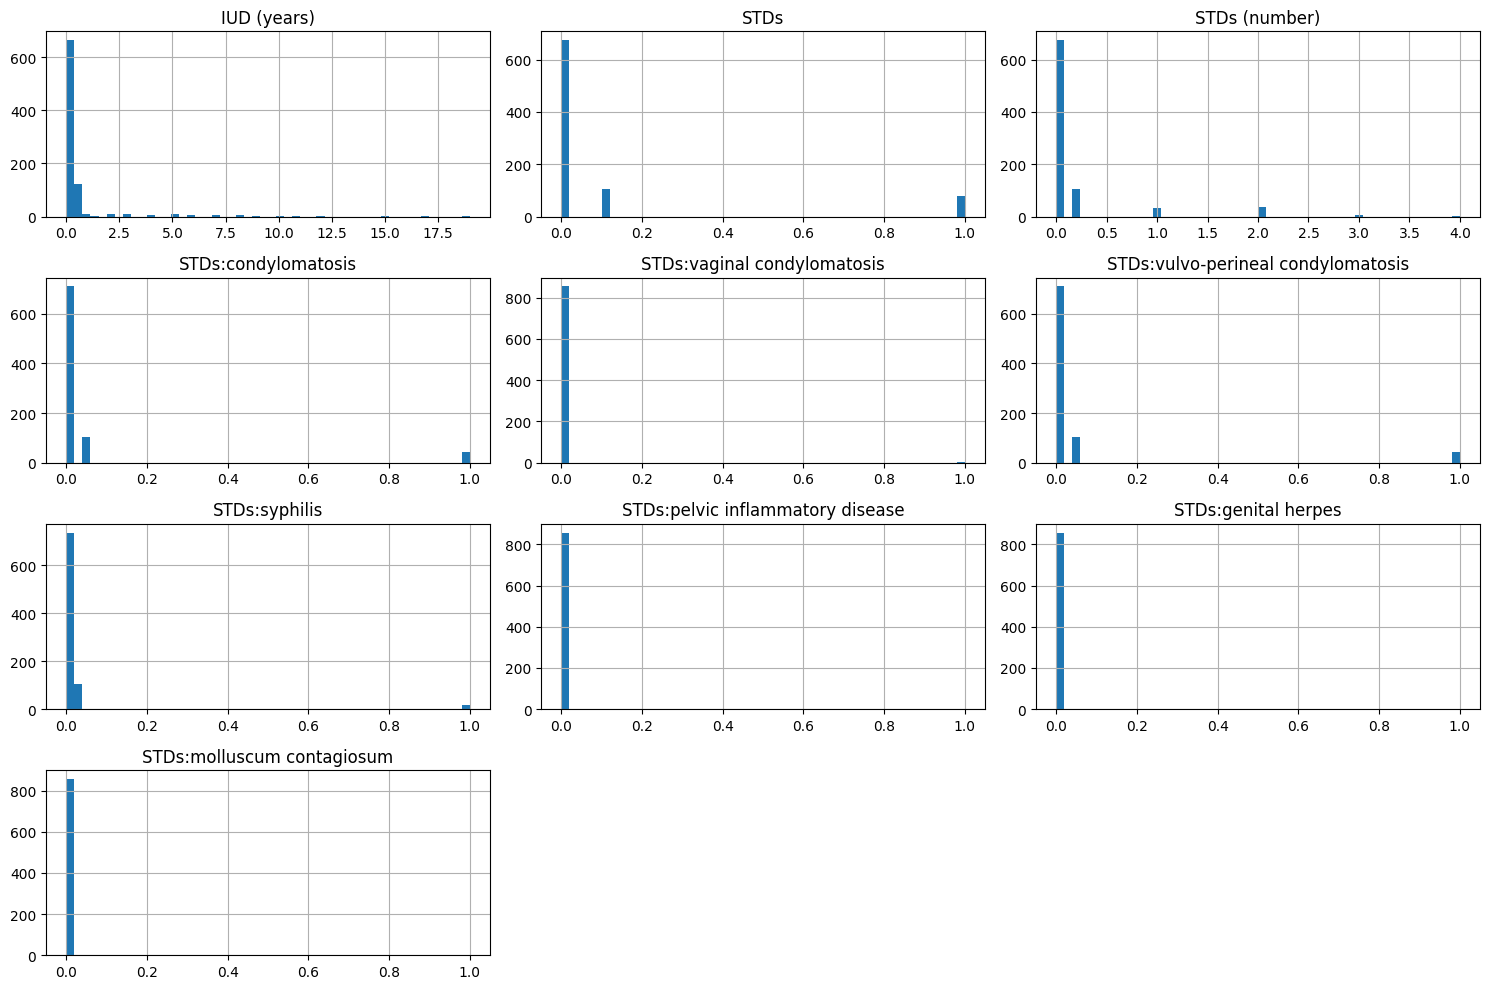

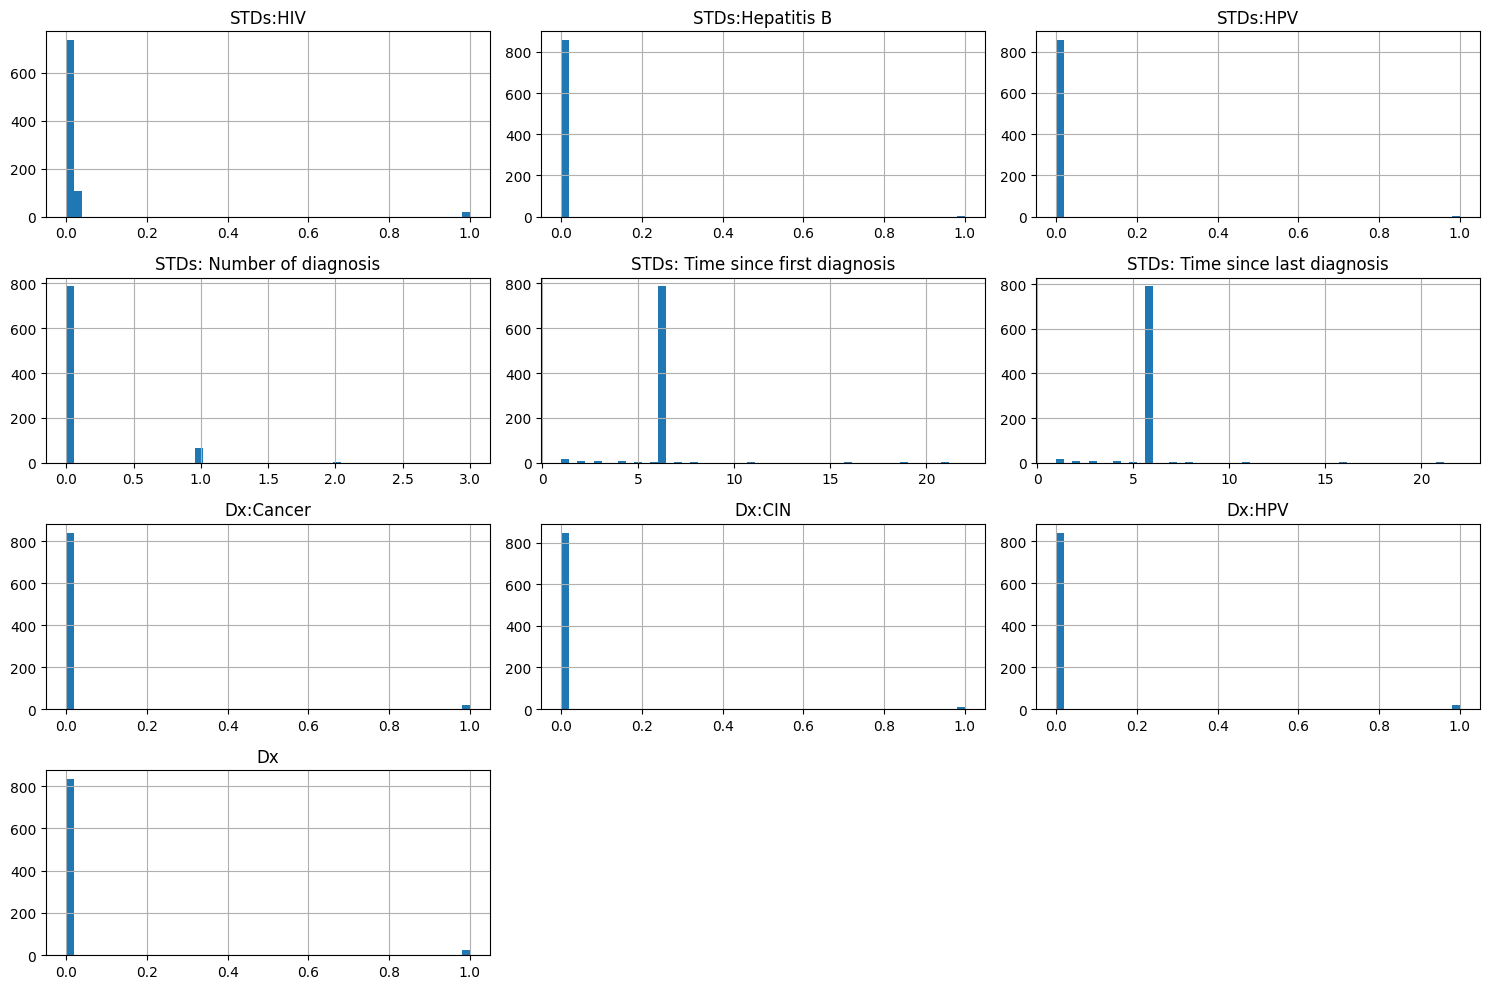

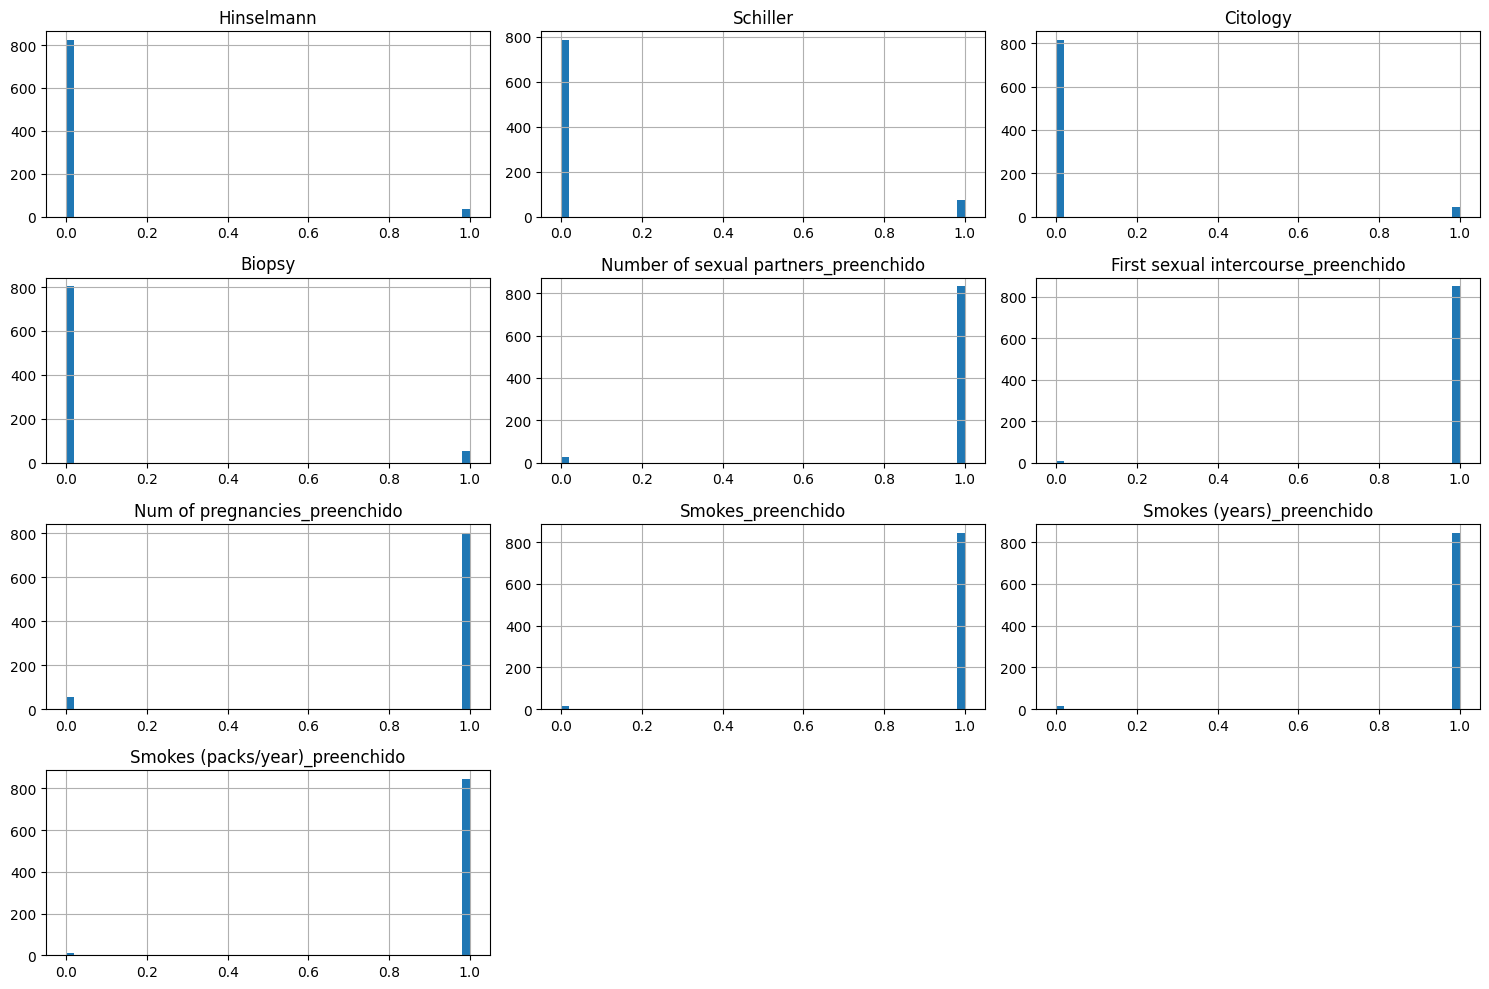

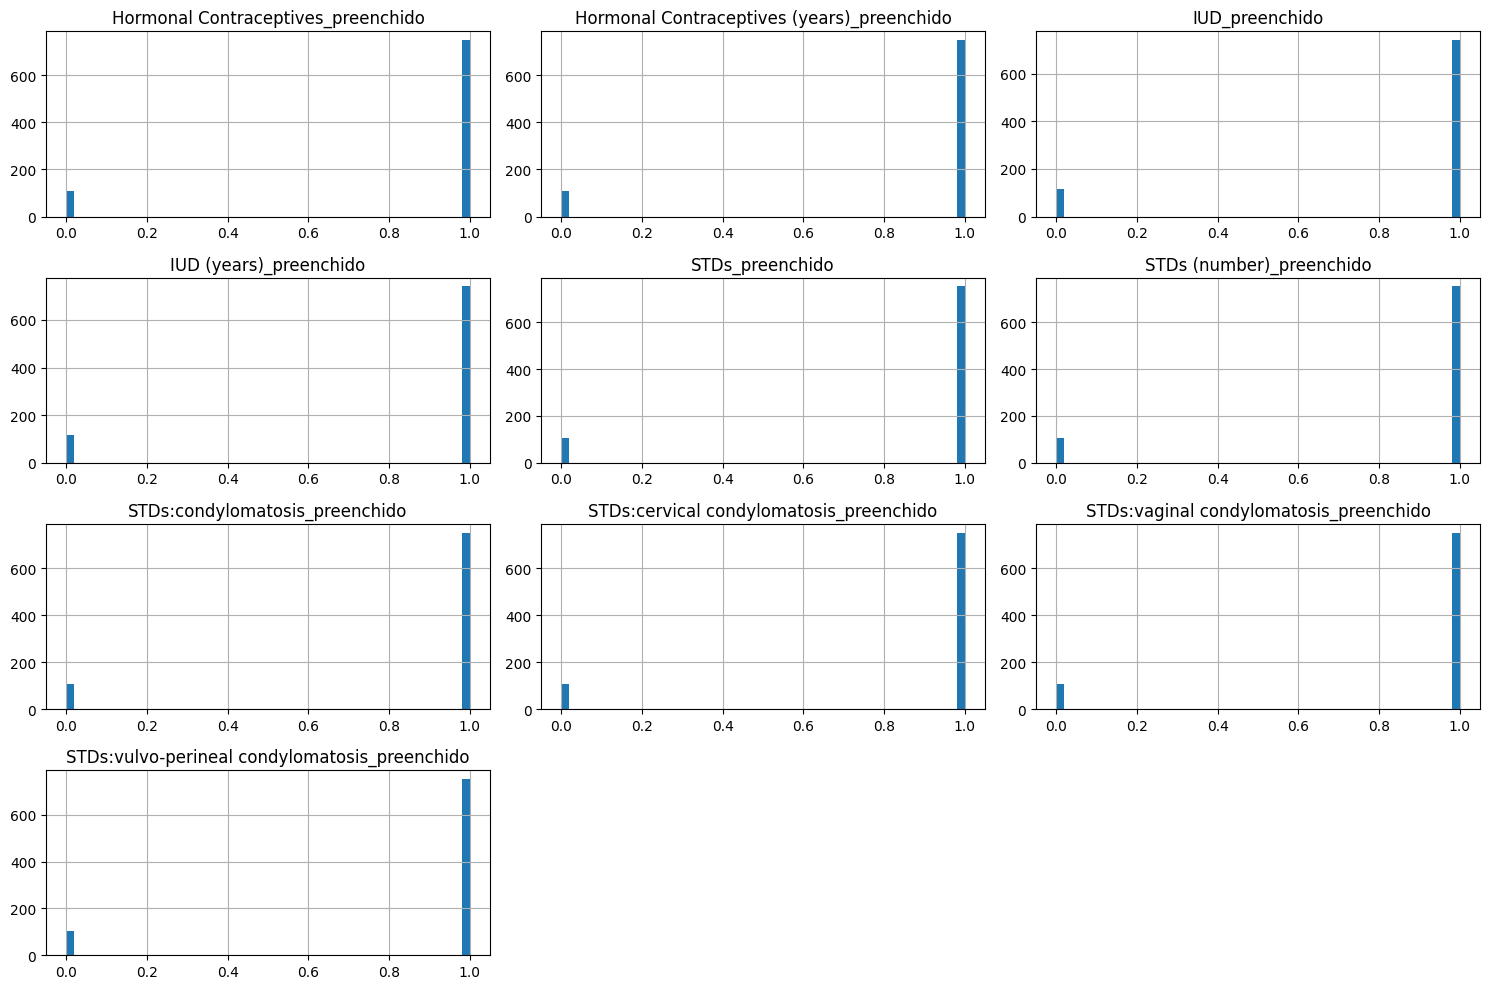

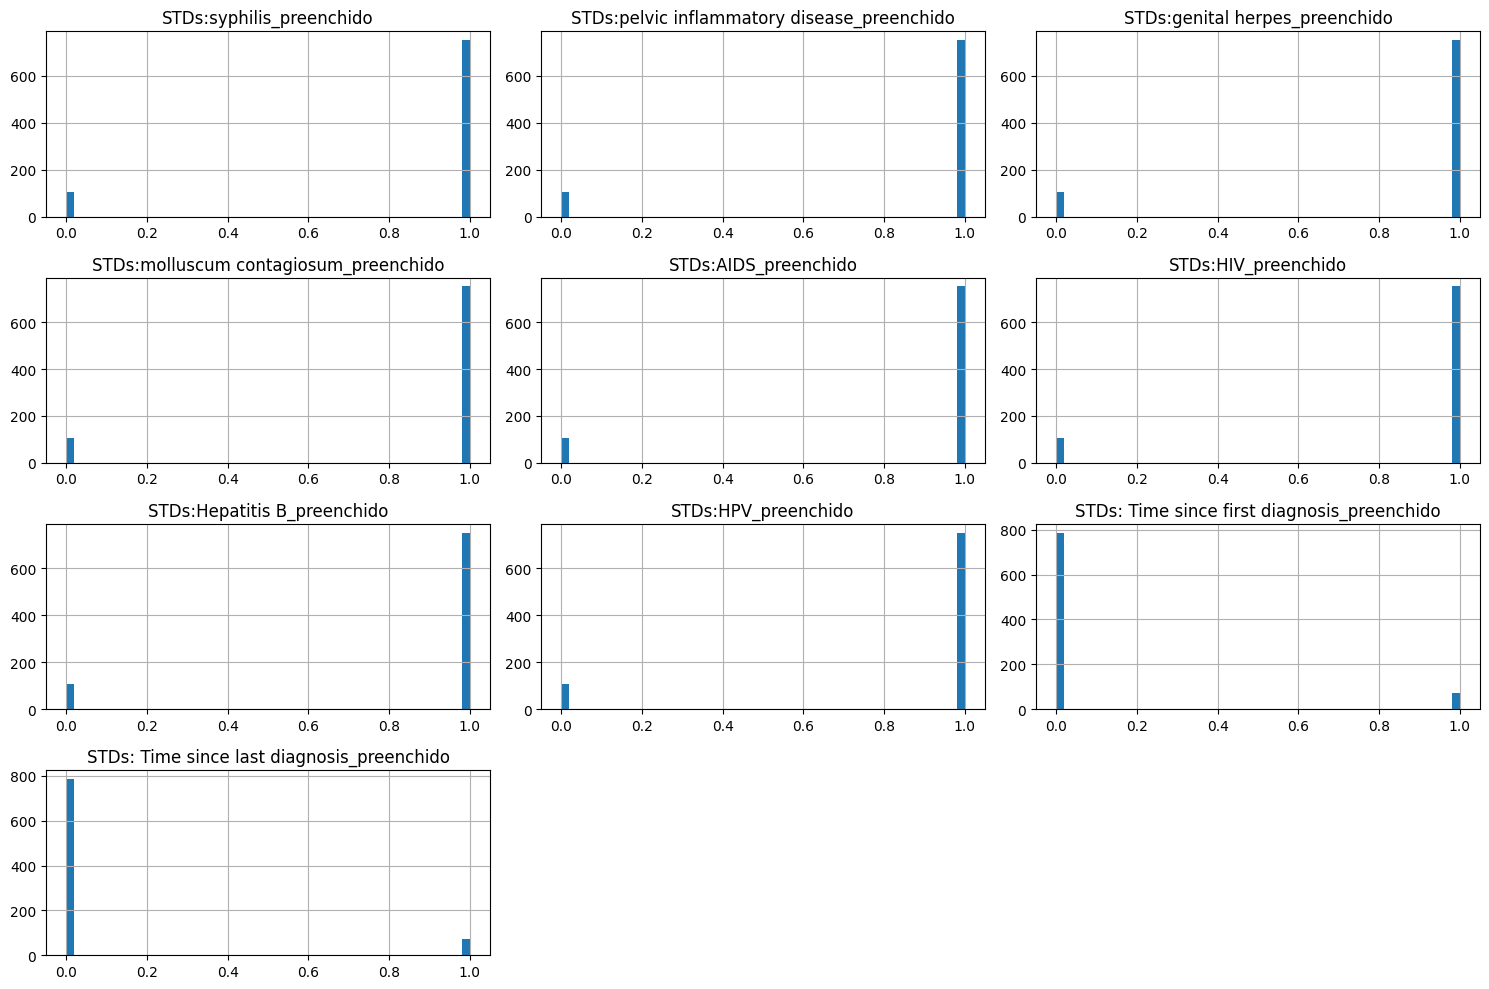

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

colunas = dataset.columns.tolist()

# dividir em blocos de 10
for i in range(0, len(colunas), 10):
    subset = colunas[i:i+10]

    dataset[subset].hist(bins=50, figsize=(15,10))
    plt.tight_layout()
    plt.show()

As novas colunas parecem iguais, contando número de registros das colunas com sufixo **preenchido**

In [14]:
colunas_preenchido = [col for col in dataset.columns if '_preenchido' in col]
for col in colunas_preenchido:
    print(col)
    print(dataset[col].value_counts(normalize=True))
    print()

Number of sexual partners_preenchido
Number of sexual partners_preenchido
1    0.969697
0    0.030303
Name: proportion, dtype: float64

First sexual intercourse_preenchido
First sexual intercourse_preenchido
1    0.991841
0    0.008159
Name: proportion, dtype: float64

Num of pregnancies_preenchido
Num of pregnancies_preenchido
1    0.934732
0    0.065268
Name: proportion, dtype: float64

Smokes_preenchido
Smokes_preenchido
1    0.984848
0    0.015152
Name: proportion, dtype: float64

Smokes (years)_preenchido
Smokes (years)_preenchido
1    0.984848
0    0.015152
Name: proportion, dtype: float64

Smokes (packs/year)_preenchido
Smokes (packs/year)_preenchido
1    0.984848
0    0.015152
Name: proportion, dtype: float64

Hormonal Contraceptives_preenchido
Hormonal Contraceptives_preenchido
1    0.874126
0    0.125874
Name: proportion, dtype: float64

Hormonal Contraceptives (years)_preenchido
Hormonal Contraceptives (years)_preenchido
1    0.874126
0    0.125874
Name: proportion, dtype: f

**É possível notar que existem alguns grupos** porque os valores são iguais:

* Grupo STDs 0 = 0.877622
* Smokes 1 = 0.984848  
* Hormonal Contraceptives 1 = 0.874126
* IUD 1 = 0.863636
* First and last Diagnosis 0 = 0.917249

Será feito o agrupamento no dataset

In [15]:
# 1. Selecionar colunas _preenchido
colunas_preenchido = [col for col in dataset.columns if '_preenchido' in col]

# 2. Agrupar colunas idênticas
grupos = {}

for col in colunas_preenchido:
    valores = tuple(dataset[col].values)

    if valores in grupos:
        grupos[valores].append(col)
    else:
        grupos[valores] = [col]

# 3. Criar novas colunas (uma por grupo) e remover redundantes
novas_colunas = []

for i, grupo in enumerate(grupos.values()):

    if len(grupo) > 1:
        # Nome da nova coluna (baseado na primeira do grupo)
        nome_base = grupo[0].replace('_preenchido', '')
        nova_coluna = f"{nome_base}_respondido"

        # Criar nova coluna (todas são iguais, então pega qualquer uma)
        dataset[nova_coluna] = dataset[grupo[0]]

        novas_colunas.append(nova_coluna)

        # Remover colunas redundantes
        dataset.drop(columns=grupo, inplace=True)

    else:
        # Se não tem grupo (coluna única), só renomeia
        col = grupo[0]
        novo_nome = col.replace('_preenchido', '_respondido')

        dataset.rename(columns={col: novo_nome}, inplace=True)
        novas_colunas.append(novo_nome)

Pode ser realizado o tratamento das variáveis de fumantes para agregar mais informações no modelo ao combinâ-las, mas antes é necessário garantir a consistência, se não fuma (zero), então faz sentido as outras serem zero também.

In [16]:
# garantir consistência
dataset.loc[dataset['Smokes'] == 0, ['Smokes (years)', 'Smokes (packs/year)']] = 0

# combinar
dataset['smoke_year_packs'] = dataset['Smokes (years)'] * dataset['Smokes (packs/year)']

# remover redundantes
dataset.drop(columns=['Smokes (years)', 'Smokes (packs/year)'], inplace=True)

Faz sentido também garantir a consitência dos contraceptivos.

In [17]:
dataset.loc[dataset['Hormonal Contraceptives'] == 0, 'Hormonal Contraceptives (years)'] = 0

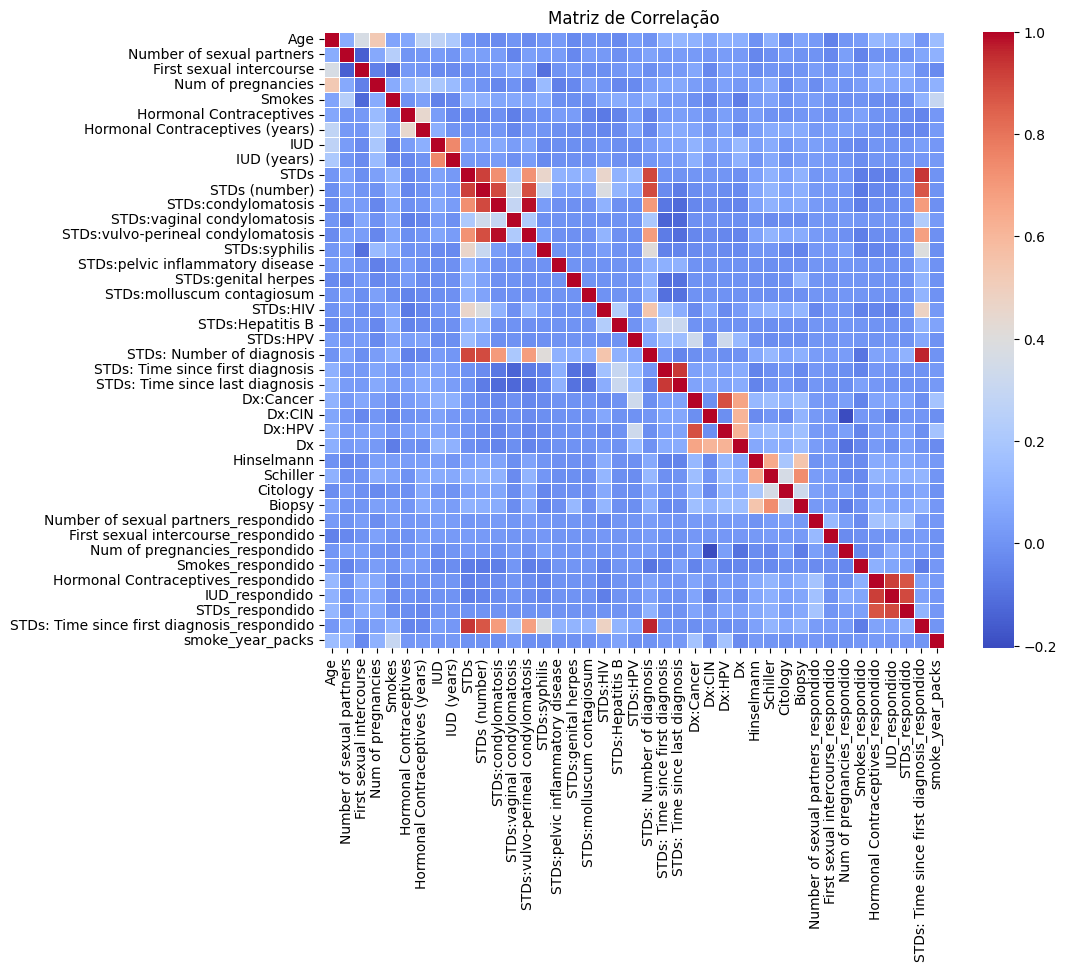

In [18]:
import numpy as np
import seaborn as sns

matriz_correlacao = dataset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, cmap='coolwarm', annot=False, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação')
plt.show()

In [19]:
dataset.nunique()

,0
Age,44
Number of sexual partners,13
First sexual intercourse,22
Num of pregnancies,12
Smokes,3
Hormonal Contraceptives,3
Hormonal Contraceptives (years),41
IUD,3
IUD (years),27
STDs,3


In [20]:
# ==============================
# 1. Imports
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ==============================
# 2. Separar features e targets
# ==============================
targets = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

X = dataset.drop(columns=targets)
y = dataset['Biopsy']

# ==============================
# 3. Split (mesmo para tudo)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ==============================
# 4. BASELINE (sem transfer learning)
# ==============================
baseline_model = RandomForestClassifier(
    class_weight={0: 1, 1: 14},
    random_state=42
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print("===== BASELINE =====")
print(classification_report(y_test, y_pred_baseline))


# ==============================
# 5. MODELOS AUXILIARES (source tasks)
# ==============================
model_hinselmann = RandomForestClassifier(class_weight={0: 1, 1: 14}, random_state=42)
model_schiller = RandomForestClassifier(class_weight={0: 1, 1: 14}, random_state=42)
model_citology = RandomForestClassifier(class_weight={0: 1, 1: 14}, random_state=42)

# Treinar usando os mesmos dados de treino
model_hinselmann.fit(X_train, dataset.loc[X_train.index, 'Hinselmann'])
model_schiller.fit(X_train, dataset.loc[X_train.index, 'Schiller'])
model_citology.fit(X_train, dataset.loc[X_train.index, 'Citology'])


# ==============================
# 6. GERAR FEATURES DE TRANSFER LEARNING
# ==============================
X_train_tl = X_train.copy()
X_test_tl = X_test.copy()

# usar probabilidades (mais informativo)
X_train_tl['hinselmann_pred'] = model_hinselmann.predict_proba(X_train)[:, 1]
X_train_tl['schiller_pred'] = model_schiller.predict_proba(X_train)[:, 1]
X_train_tl['citology_pred'] = model_citology.predict_proba(X_train)[:, 1]

X_test_tl['hinselmann_pred'] = model_hinselmann.predict_proba(X_test)[:, 1]
X_test_tl['schiller_pred'] = model_schiller.predict_proba(X_test)[:, 1]
X_test_tl['citology_pred'] = model_citology.predict_proba(X_test)[:, 1]


# ==============================
# 7. MODELO FINAL (com transfer learning)
# ==============================
model_final = RandomForestClassifier(
    class_weight={0: 1, 1: 14},
    random_state=42
)

model_final.fit(X_train_tl, y_train)

y_pred_tl = model_final.predict(X_test_tl)

print("\n===== TRANSFER LEARNING =====")
print(classification_report(y_test, y_pred_tl))

===== BASELINE =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       161
           1       0.50      0.09      0.15        11

    accuracy                           0.94       172
   macro avg       0.72      0.54      0.56       172
weighted avg       0.91      0.94      0.91       172


===== TRANSFER LEARNING =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       161
           1       0.50      0.09      0.15        11

    accuracy                           0.94       172
   macro avg       0.72      0.54      0.56       172
weighted avg       0.91      0.94      0.91       172

